In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Загрузка данных
wages_file = "номинальные зарплаты РФ 2000-2024.xlsx"
gdp_file = "ВВП по годам.xlsx"
inflation_file = "инфляция РФ по годам.xlsx"

ModuleNotFoundError: No module named 'pandas'

In [18]:
# Зарплаты
wages_df = pd.read_excel(wages_file, header=None)
wages_years = pd.to_numeric(wages_df.iloc[0, 1:], errors='coerce')
wages_df.columns = ['Отрасль'] + wages_years.tolist()
wages_df = wages_df.drop(index=0)
wages_df.set_index('Отрасль', inplace=True)
wages_df = wages_df.loc[:, ~wages_df.columns.isna()]
wages_df = wages_df.apply(pd.to_numeric, errors='coerce')


In [19]:
#Выбор отраслей
industries = ['Добыча полезных ископаемых', 'Финансовая деятельность']
selected_wages = wages_df.loc[industries].transpose()


In [20]:
# Инфляция
inflation_df = pd.read_excel(inflation_file, index_col=0).transpose()
inflation_df.columns = ['Инфляция']
inflation_df.index = inflation_df.index.astype(int)
inflation_series = inflation_df['Инфляция']

In [21]:
# ВВП
gdp_df = pd.read_excel(gdp_file, index_col=0).transpose()
gdp_df.columns = ['ВВП номинальный']
gdp_df.index = gdp_df.index.astype(int)
gdp_series = gdp_df['ВВП номинальный']

In [22]:
# Общие года
common_years = wages_df.columns.intersection(gdp_series.index).intersection(inflation_series.index)
wages_df = wages_df[common_years]
gdp_series = gdp_series.loc[common_years]
inflation_series = inflation_series.loc[common_years]

In [23]:
# Транспонирование для расчетов
wages_df_T = wages_df.transpose()

# Реальные значения
inflation_cum = (1 + inflation_series / 100).cumprod()
real_wages = wages_df_T.div(inflation_cum, axis=0)
real_gdp = gdp_series.div(inflation_cum)

In [24]:
# Темпы роста
wage_growth_nominal = wages_df_T.pct_change() * 100
wage_growth_real = real_wages.pct_change() * 100
gdp_growth = gdp_series.pct_change() * 100

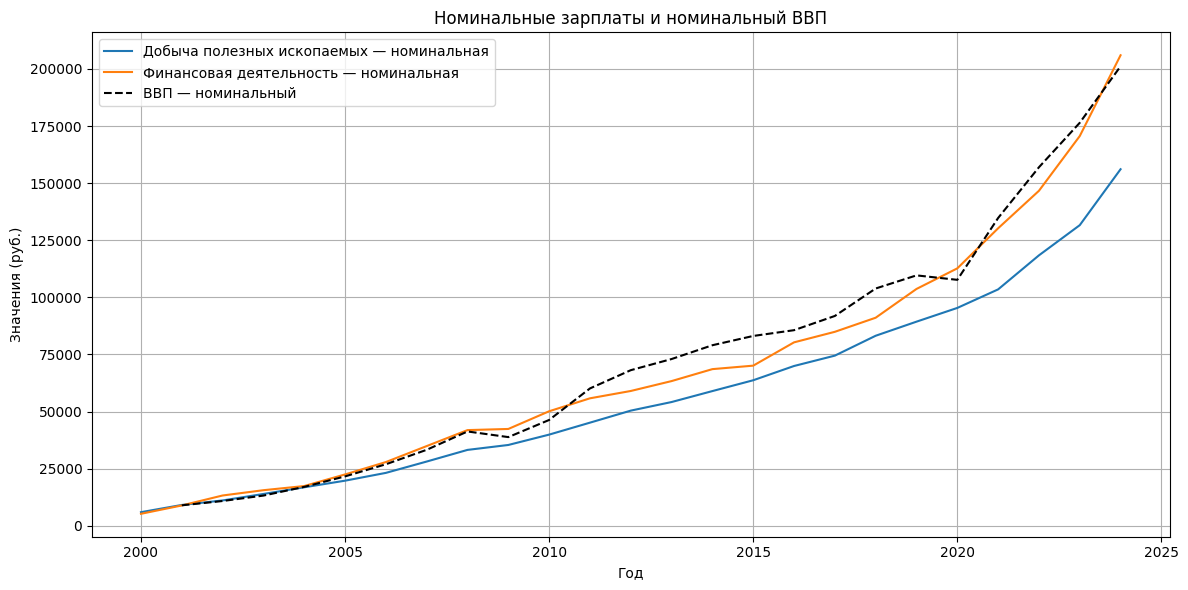

In [25]:
#График 1: номинальные зарплаты + номинальный ВВП
plt.figure(figsize=(12, 6))
for col in selected_wages.columns:
    plt.plot(selected_wages.index, selected_wages[col], label=f'{col} — номинальная')
plt.plot(gdp_series.index, gdp_series.values, label='ВВП — номинальный', linestyle='--', color='black')
plt.title('Номинальные зарплаты и номинальный ВВП')
plt.xlabel('Год')
plt.ylabel('Значения (руб.)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Выводы и аналитика по блоку номинальных показателей представлена в конце документа (вместе с остальной аналитикой) в соответствии с логикой создаваемого web-приложения

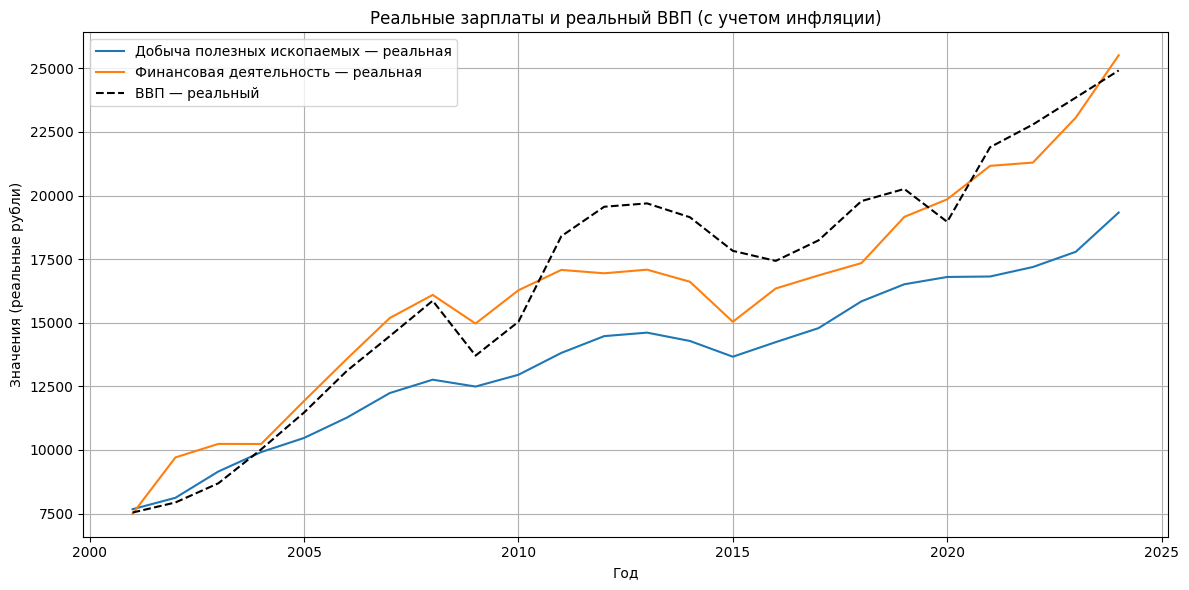

In [26]:
#График 2: реальные зарплаты + реальный ВВП
plt.figure(figsize=(12, 6))
for col in real_wages.columns:
    plt.plot(real_wages.index, real_wages[col], label=f'{col} — реальная')
plt.plot(real_gdp.index, real_gdp.values, label='ВВП — реальный', linestyle='--', color='black')
plt.title('Реальные зарплаты и реальный ВВП (с учетом инфляции)')
plt.xlabel('Год')
plt.ylabel('Значения (реальные рубли)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
#График 3: темпы роста
nominal_growth = selected_wages.pct_change() * 100
real_growth = real_wages.pct_change() * 100
gdp_growth = gdp_series.pct_change() * 100

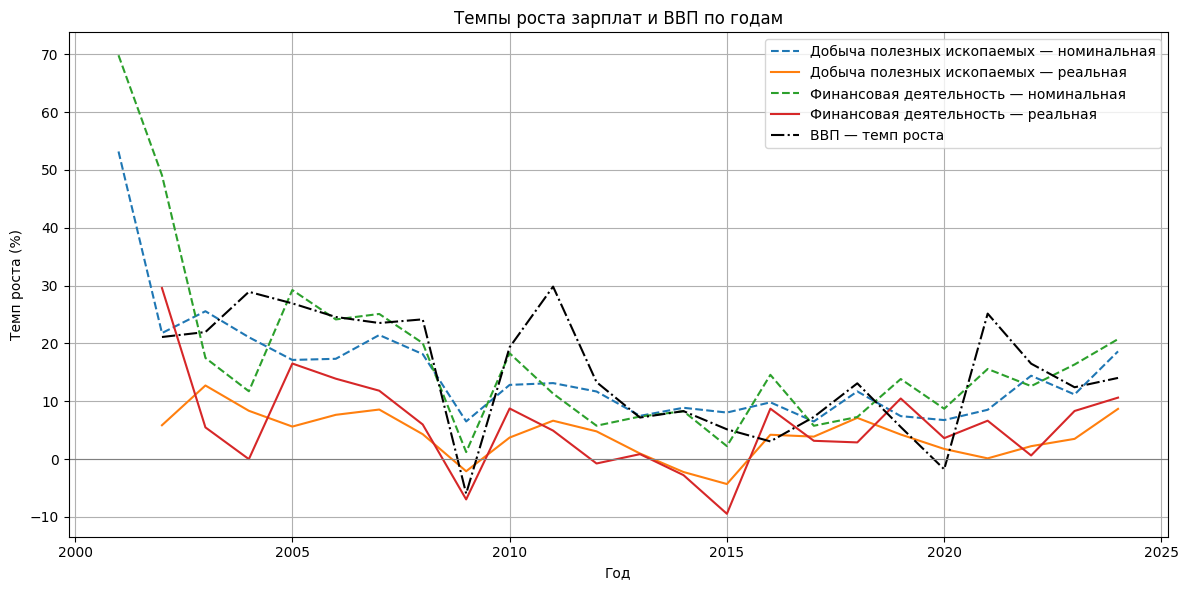

In [28]:
#График темпов роста
plt.figure(figsize=(12, 6))
for col in nominal_growth.columns:
    plt.plot(nominal_growth.index, nominal_growth[col], linestyle='--', label=f'{col} — номинальная')
    plt.plot(real_growth.index, real_growth[col], linestyle='-', label=f'{col} — реальная')
plt.plot(gdp_growth.index, gdp_growth.values, label='ВВП — темп роста', linestyle='-.', color='black')
plt.axhline(0, color='gray', linewidth=0.8)
plt.title('Темпы роста зарплат и ВВП по годам')
plt.xlabel('Год')
plt.ylabel('Темп роста (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Далее представлена аналитика и выводы (в том числе по графику "Номинальные зарплаты и номинальный ВВП")

In [39]:
for col in wages_df.index:
    col_nom = wages_df_T[col]
    col_real = real_wages[col]

    start_val = col_nom.iloc[0]
    end_val = col_nom.iloc[-1]
    n_years = len(col_nom) - 1
    if start_val > 0:
        cagr = ((end_val / start_val) ** (1 / n_years) - 1) * 100
        print(f"{col} — CAGR ≈ {cagr:.2f}%")

    growth_nom = col_nom.pct_change().dropna() * 100
    growth_real = col_real.pct_change().dropna() * 100

    if not growth_nom.empty:
        print(f"{col} — номинальный рост:")
        print(f"- Мин: {growth_nom.min():.2f}% в {int(growth_nom.idxmin())}")
        print(f"- Макс: {growth_nom.max():.2f}% в {int(growth_nom.idxmax())}")

    if not growth_real.empty:
        print(f"{col} — реальный рост:")
        print(f"- Мин: {growth_real.min():.2f}% в {int(growth_real.idxmin())}")
        print(f"- Макс: {growth_real.max():.2f}% в {int(growth_real.idxmax())}")

Добыча полезных ископаемых — CAGR ≈ 13.15%
Добыча полезных ископаемых — номинальный рост:
- Мин: 6.49% в 2017
- Макс: 25.55% в 2003
Добыча полезных ископаемых — реальный рост:
- Мин: -4.33% в 2015
- Макс: 12.71% в 2003
Финансовая деятельность — CAGR ≈ 14.64%
Финансовая деятельность — номинальный рост:
- Мин: 1.20% в 2009
- Макс: 49.08% в 2002
Финансовая деятельность — реальный рост:
- Мин: -9.47% в 2015
- Макс: 29.57% в 2002


In [30]:
for col in wages_df_T.columns:
    wage_gr = wages_df_T[col].pct_change().dropna()
    gdp_gr = gdp_series.pct_change().dropna()
    common = wage_gr.index.intersection(gdp_gr.index)
    corr = wage_gr.loc[common].corr(gdp_gr.loc[common])

    print(f"{col}: корреляция роста зарплат и ВВП = {corr:.2f}")

Добыча полезных ископаемых: корреляция роста зарплат и ВВП = 0.73
Финансовая деятельность: корреляция роста зарплат и ВВП = 0.55


In [53]:
for col in wage_growth_real.columns:
    years_outpace = wage_growth_real[col][wage_growth_real[col] > inflation_series].index.tolist()
    years_outpace = list(map(int, years_outpace))
    print(f"{col}: рост зарплат обгонял инфляцию в годы: {', '.join(map(str, years_outpace))}")

Добыча полезных ископаемых: рост зарплат обгонял инфляцию в годы: 2003, 2011, 2017, 2018, 2019
Финансовая деятельность: рост зарплат обгонял инфляцию в годы: 2002, 2005, 2006, 2016, 2017, 2019, 2023, 2024
